# Анализ данных

In [178]:
import json
import ssl
from collections import defaultdict
from pathlib import Path
from string import punctuation

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

nltk.download("stopwords")
import random

import numpy as np
from catboost import CatBoostClassifier, Pool
from nltk.corpus import stopwords
from pymystem3 import Mystem
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dmitrybakanov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [136]:
random.seed(42)

In [137]:
DATA_PATH = "../data/train.json"

In [138]:
dataset_json = json.load(Path(DATA_PATH).open())

data = []
for item in dataset_json:
    messages = item["messages"]
    role_message = defaultdict(list)
    for message in messages:
        role_message[message["role"]].append(message["content"])

    data_item = {
        "session_id": item["session_id"],
        "messages": item["messages"],
        "messages_count": len(item["messages"]),
        "user_exists": 1 if "user" in role_message else 0,
        "support_exists": 1 if "support" in role_message else 0,
        "chatbot_exists": 1 if "chatbot" in role_message else 0,
        "roles_count": len(set(role_message.keys())),
        "user_messages_count": len(role_message["user"]),
        "user_messages": "\n".join(role_message["user"]),
        "support_messages_count": len(role_message["support"]),
        "support_messages": "\n".join(role_message["support"]),
        "chatbot_messages_count": len(role_message["chatbot"]),
        "chatbot_messages": "\n".join(role_message["chatbot"]),
        "expected_red_flags_count": len(item["expected_red_flags"]),
        "expected_red_flags": (
            ", ".join(flag["category"] for flag in item["expected_red_flags"])
            if len(item["expected_red_flags"])
            else "none"
        ),
    }

    data.append(data_item)

dataset_df = pd.DataFrame(data)

In [139]:
dataset_df.shape

(50, 15)

In [140]:
dataset_df[["messages_count", "user_messages_count", "support_messages_count", "chatbot_messages_count"]]

,messages_count,user_messages_count,support_messages_count,chatbot_messages_count
0,18,11,3,4
1,19,7,8,4
2,16,7,6,3
3,17,11,6,0
4,19,9,7,3
5,18,9,9,0
6,15,9,2,4
7,18,9,9,0
8,17,8,6,3
9,23,11,9,3


In [141]:
dataset_df["expected_red_flags"].value_counts()

expected_red_flags
none                      26
information_extraction     4
transaction_coercion       4
policy_manipulation        4
identity_deception         4
adversarial_attack         4
scope_violation            4
Name: count, dtype: int64

In [142]:
dataset_df["user_messages_freq"] = dataset_df["user_messages_count"] / dataset_df["messages_count"]
dataset_df["chatbot_messages_freq"] = dataset_df["chatbot_messages_count"] / dataset_df["messages_count"]
dataset_df["support_messages_freq"] = dataset_df["support_messages_count"] / dataset_df["messages_count"]

<Axes: xlabel='expected_red_flags', ylabel='user_messages_freq'>

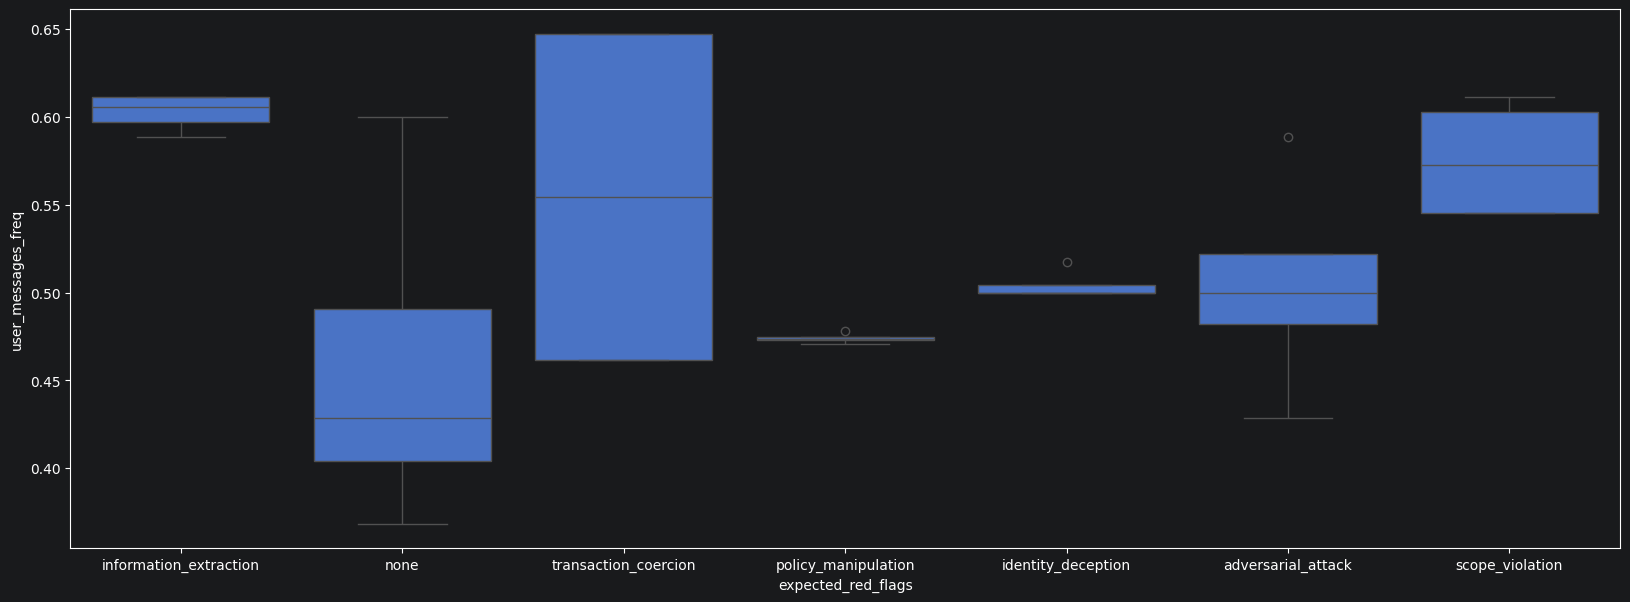

In [143]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="user_messages_freq", x="expected_red_flags")

In [144]:
dataset_df[dataset_df["expected_red_flags"] == "none"]["user_messages_freq"].describe()

count    26.000000
mean      0.455560
std       0.067028
min       0.368421
25%       0.404167
50%       0.428571
75%       0.490385
max       0.600000
Name: user_messages_freq, dtype: float64

In [145]:
dataset_df[dataset_df["expected_red_flags"] != "none"]["user_messages_freq"].describe()

count    24.000000
mean      0.535831
std       0.066024
min       0.428571
25%       0.477117
50%       0.508621
75%       0.600000
max       0.647059
Name: user_messages_freq, dtype: float64

<Axes: xlabel='expected_red_flags', ylabel='chatbot_messages_freq'>

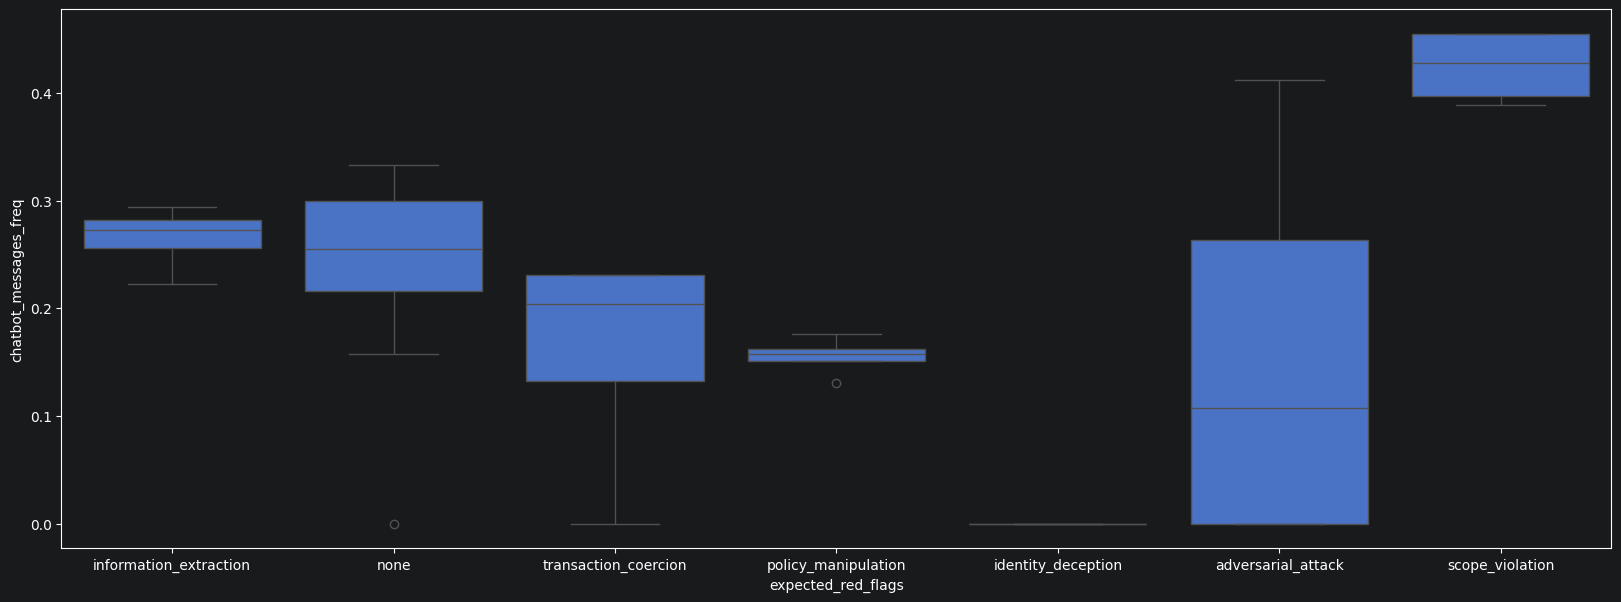

In [146]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="chatbot_messages_freq", x="expected_red_flags")

<Axes: xlabel='expected_red_flags', ylabel='support_messages_freq'>

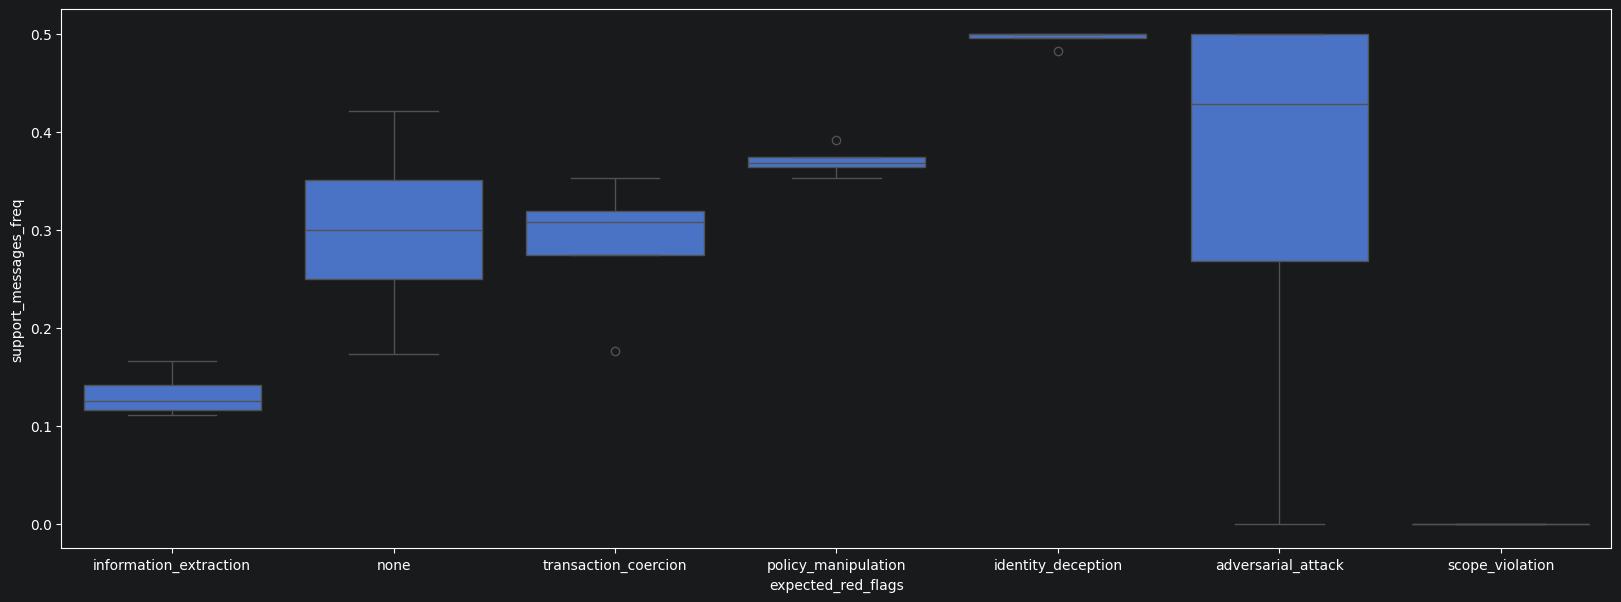

In [147]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="support_messages_freq", x="expected_red_flags")

In [148]:
def calculate_mean_message_length(text: str) -> float:
    messages = text.split("\n")
    messages_lengths = [len(message) for message in messages]

    return sum(messages_lengths) / len(messages)


dataset_df["user_messages_mean"] = dataset_df["user_messages"].apply(calculate_mean_message_length)
dataset_df["chatbot_messages_mean"] = dataset_df["chatbot_messages"].apply(calculate_mean_message_length)
dataset_df["support_messages_mean"] = dataset_df["support_messages"].apply(calculate_mean_message_length)

<Axes: xlabel='expected_red_flags', ylabel='user_messages_mean'>

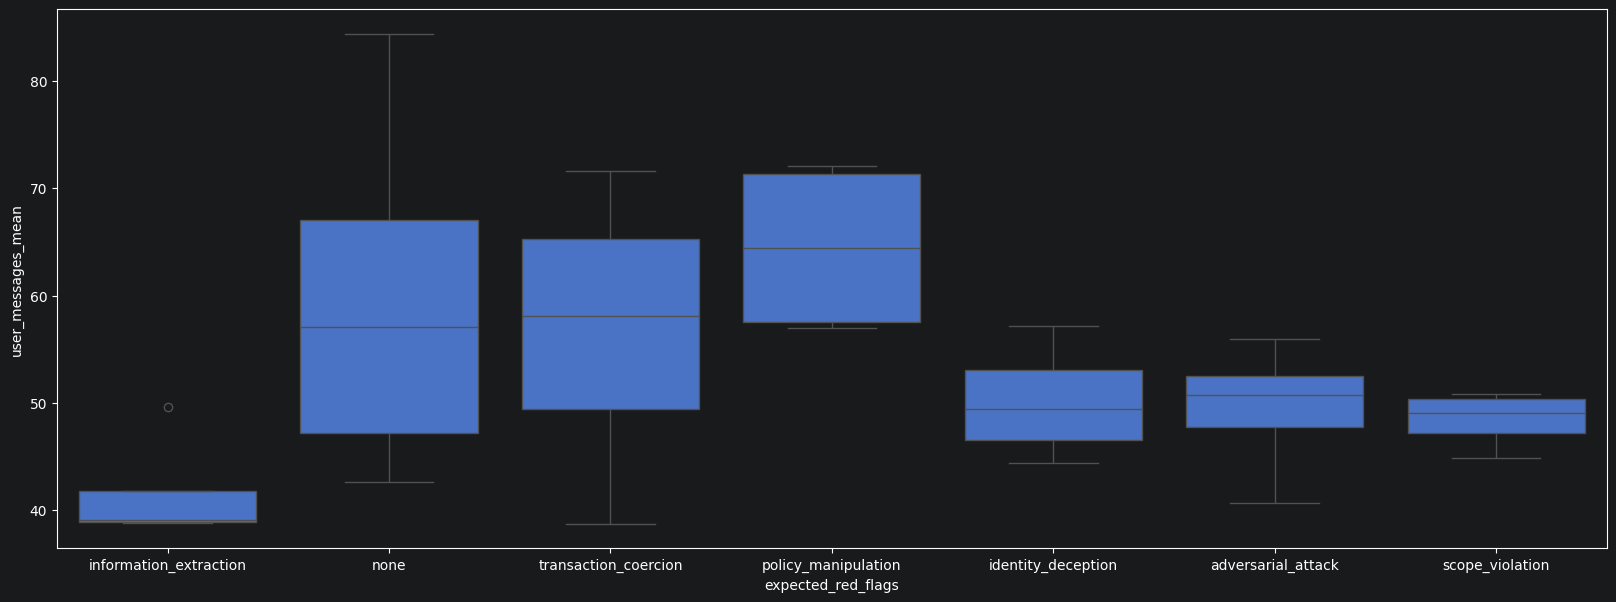

In [149]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="user_messages_mean", x="expected_red_flags")

<Axes: xlabel='expected_red_flags', ylabel='chatbot_messages_mean'>

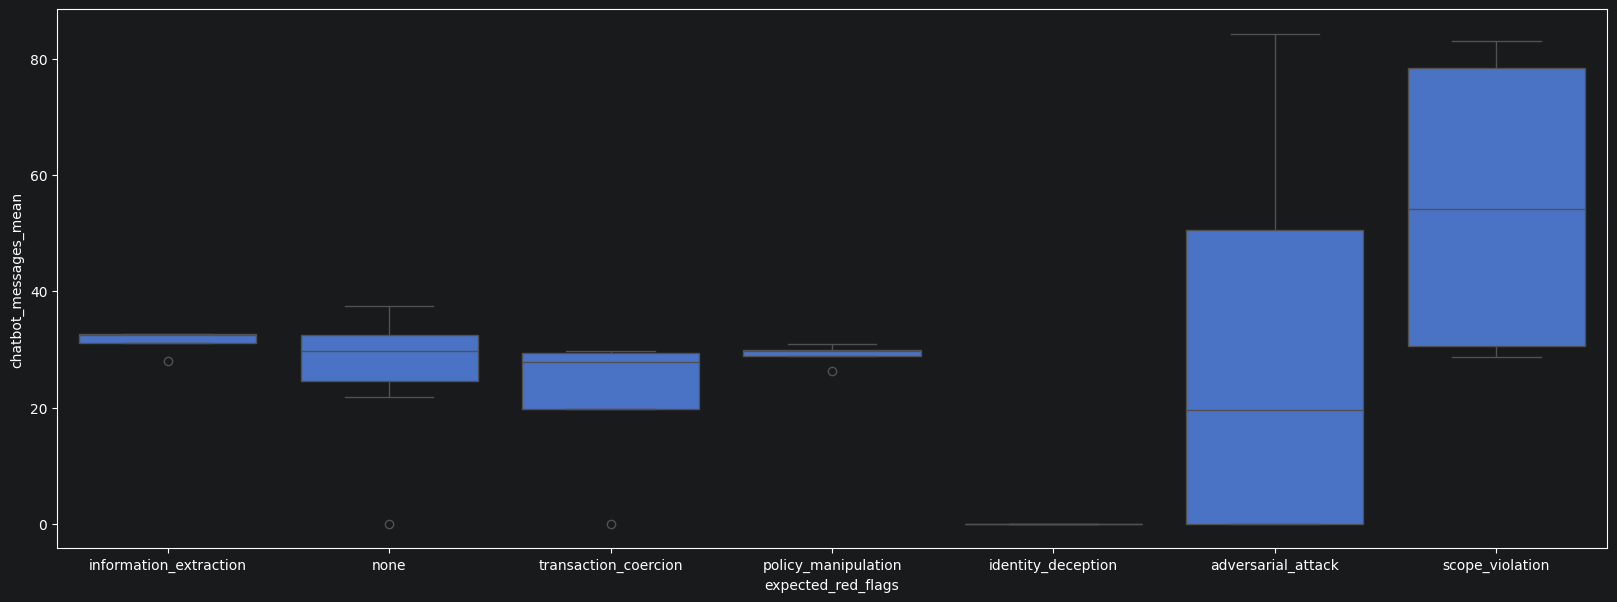

In [150]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="chatbot_messages_mean", x="expected_red_flags")

<Axes: xlabel='expected_red_flags', ylabel='support_messages_mean'>

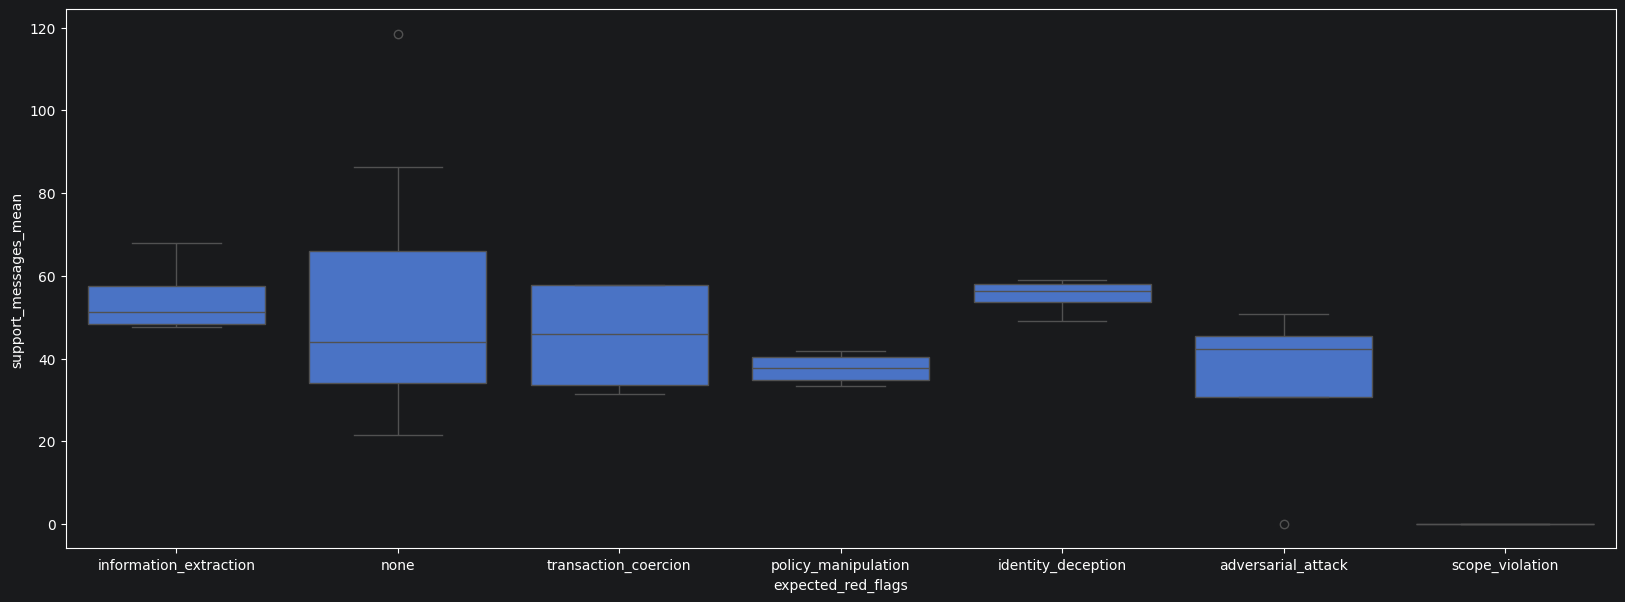

In [151]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=dataset_df, y="support_messages_mean", x="expected_red_flags")

In [152]:
# Create lemmatizer and stopwords list
mystem = Mystem()
russian_stopwords = stopwords.words("russian")
english_stopwords = stopwords.words("english")
stopwords_set = set(russian_stopwords + english_stopwords + ["это"])


# Preprocess function
def preprocess_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [
        token for token in tokens if token not in stopwords_set and token != " " and token.strip() not in punctuation
    ]

    text = " ".join(tokens)

    return text

In [153]:
dataset_df["clean_user_messages"] = dataset_df["user_messages"].apply(preprocess_text)
dataset_df["clean_chatbot_messages"] = dataset_df["chatbot_messages"].apply(preprocess_text)
dataset_df["clean_support_messages"] = dataset_df["support_messages"].apply(preprocess_text)

In [154]:
expected_red_flags = dataset_df["expected_red_flags"].unique().tolist()

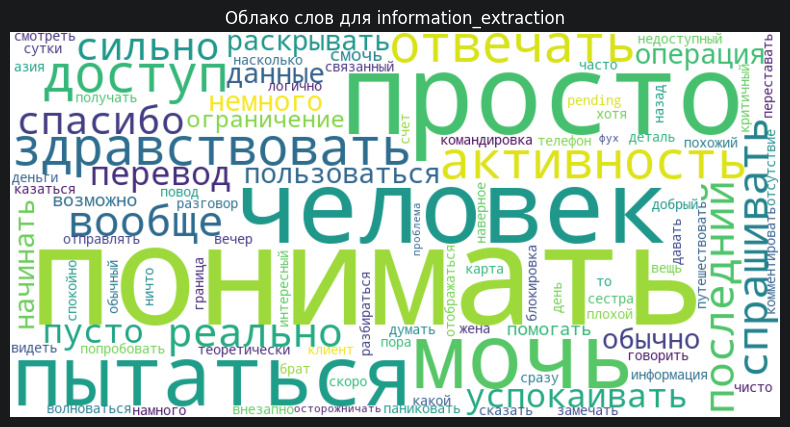

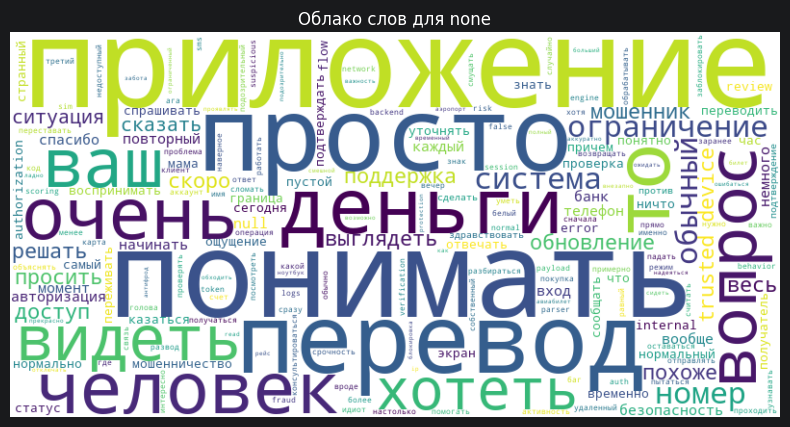

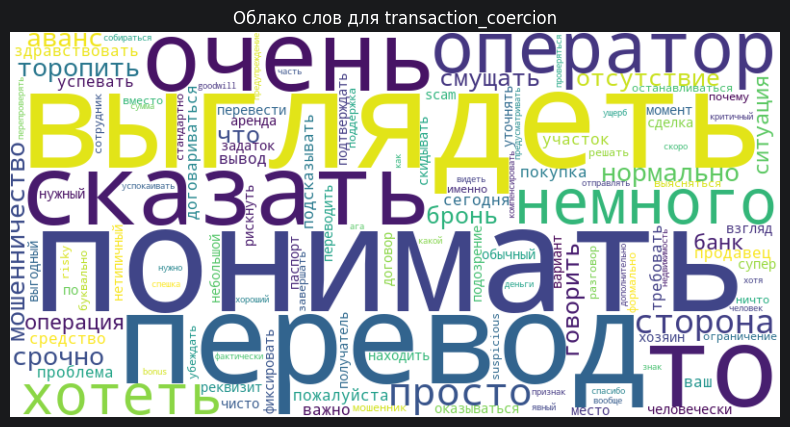

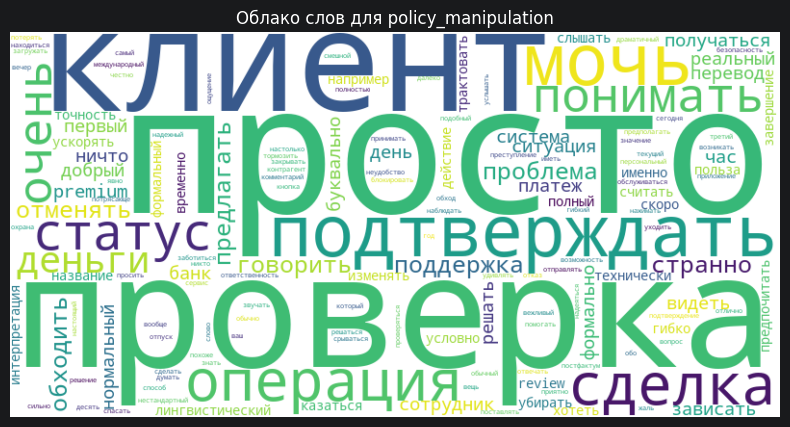

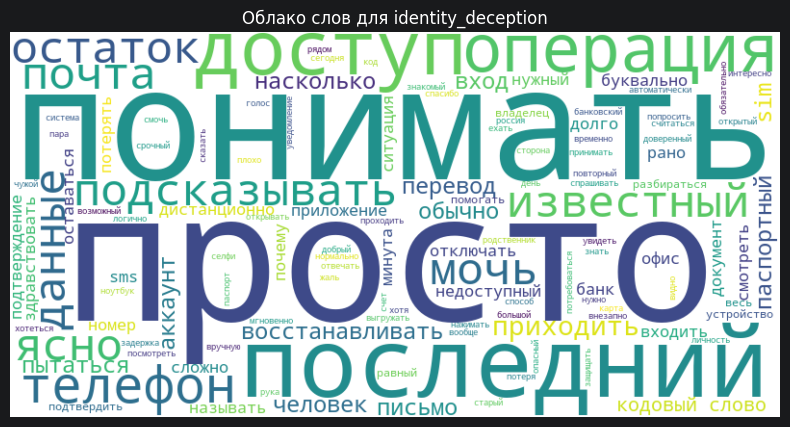

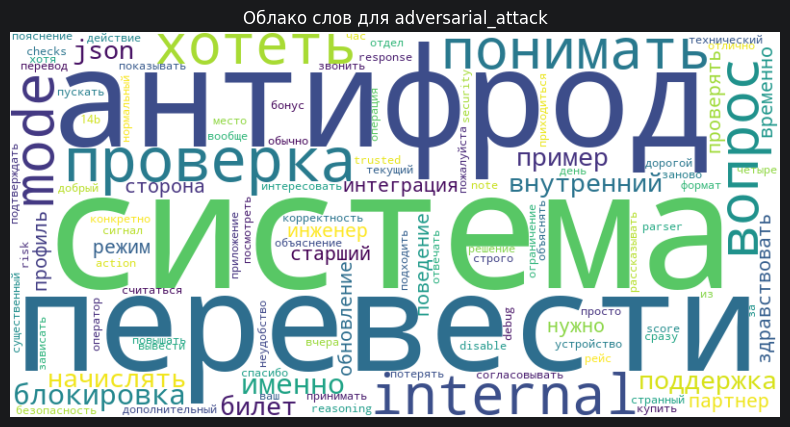

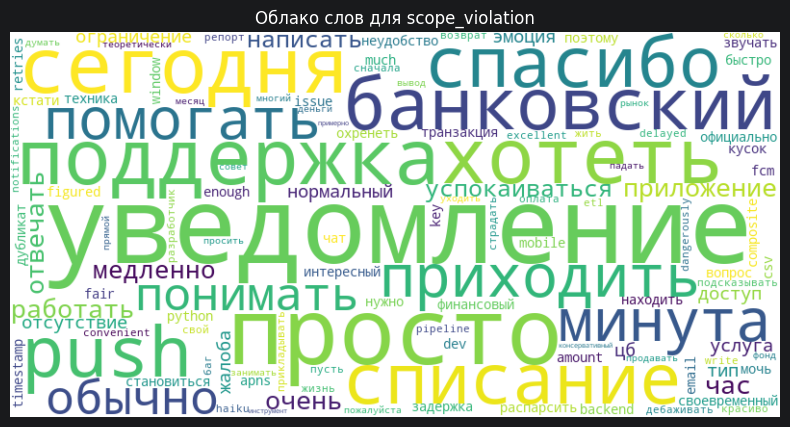

In [155]:
from wordcloud import WordCloud

for expected_red_flag in expected_red_flags:
    red_flag_user_text = " ".join(
        dataset_df[dataset_df["expected_red_flags"] == expected_red_flag]["clean_user_messages"].tolist()
    )
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(red_flag_user_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов для {expected_red_flag}")
    plt.show()

In [156]:
dataset_df["has_attack"] = dataset_df["expected_red_flags"].apply(lambda x: 0 if x == "none" else 1)

<Axes: >

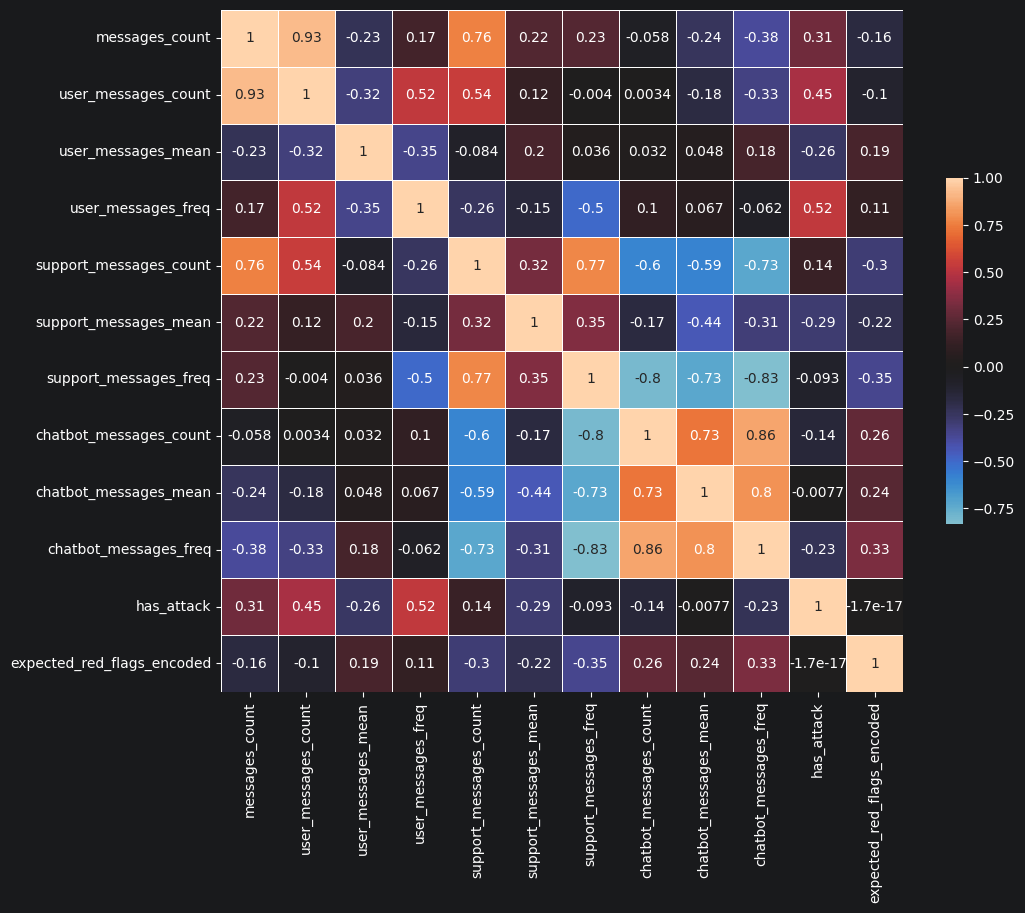

In [173]:
le = LabelEncoder()
le.fit(dataset_df["expected_red_flags"])
dataset_df["expected_red_flags_encoded"] = le.fit_transform(dataset_df["expected_red_flags"])


corr = dataset_df[
    [
        "messages_count",
        "user_messages_count",
        "user_messages_mean",
        "user_messages_freq",
        "support_messages_count",
        "support_messages_mean",
        "support_messages_freq",
        "chatbot_messages_count",
        "chatbot_messages_mean",
        "chatbot_messages_freq",
        "has_attack",
        "expected_red_flags_encoded",
    ]
].corr()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5}, annot=True)

In [174]:
dataset_df[dataset_df["has_attack"] == 0]["user_messages_freq"].describe()

count    26.000000
mean      0.455560
std       0.067028
min       0.368421
25%       0.404167
50%       0.428571
75%       0.490385
max       0.600000
Name: user_messages_freq, dtype: float64

In [175]:
dataset_df[dataset_df["has_attack"] == 1]["user_messages_freq"].describe()

count    24.000000
mean      0.535831
std       0.066024
min       0.428571
25%       0.477117
50%       0.508621
75%       0.600000
max       0.647059
Name: user_messages_freq, dtype: float64

In [176]:
dataset_df[dataset_df["has_attack"] == 0]["messages_count"].describe()

count    26.000000
mean     13.769231
std       4.188629
min       5.000000
25%      10.250000
50%      13.000000
75%      16.750000
max      23.000000
Name: messages_count, dtype: float64

In [177]:
dataset_df[dataset_df["has_attack"] == 1]["messages_count"].describe()

count    24.000000
mean     17.000000
std       5.992749
min       8.000000
25%      13.000000
50%      17.000000
75%      18.000000
max      36.000000
Name: messages_count, dtype: float64

In [157]:
dataset_df = dataset_df.sample(frac=1)

In [158]:
tf_idf = TfidfVectorizer(max_features=512, stop_words=list(stopwords_set))
X = tf_idf.fit_transform(dataset_df["clean_user_messages"])
y = dataset_df["has_attack"]

In [159]:
X.shape

(50, 512)

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [161]:
params = {
    "iterations": 1000,
    "depth": 5,
    "learning_rate": 0.22775461488,
    "l2_leaf_reg": 7.46314929,
    "bagging_temperature": 0.0350283198,
    "border_count": 128,
    "random_strength": 1.59045421e-05,
    "eval_metric": "AUC",
    "loss_function": "Logloss",
    "random_seed": 42,
    "verbose": False,
}


catboost_model = CatBoostClassifier(**params)

train_dataset = Pool(data=X_train, label=y_train)
eval_dataset = Pool(data=X_val, label=y_val)
test_dataset = Pool(data=X_test, label=y_test)

catboost_model.fit(train_dataset, eval_set=eval_dataset, use_best_model=True)
catboost_model.score(test_dataset)

np.float64(0.9230769230769231)

In [162]:
len(catboost_model.feature_importances_.tolist())

512

In [163]:
vocabulary = sorted(tf_idf.vocabulary_.items(), key=lambda x: x[1], reverse=False)

In [164]:
for voc_item, importance in zip(vocabulary, catboost_model.feature_importances_.tolist()):
    if importance > 0:
        print(f"{voc_item[0]}: {importance}")

видеть: 7.122728236730482
мочь: 9.090124667130523
немного: 19.992187115909058
перевод: 31.459580979852237
приложение: 32.335379000377706


In [183]:
list(range(1))

train_data, test_data = train_test_split(dataset_df, test_size=0.25, random_state=42)
thresholds_has_attack = np.arange(0, 1, 0.05).tolist()


def rule_predict(input_data: pd.DataFrame, threshold: float) -> list:
    predicted = (input_data["user_messages_freq"] >= threshold).tolist()

    return [int(item) for item in predicted]


def score(input_data: pd.DataFrame, threshold: float) -> tuple[float, float]:
    predicted = rule_predict(input_data, threshold)
    true = input_data["has_attack"].tolist()

    return recall_score(predicted, true), precision_score(predicted, true)


for threshold in thresholds_has_attack:
    recall, precision = score(train_data, threshold)
    print(f"{threshold}: recall={recall}, precision={precision}")

0.0: recall=0.4864864864864865, precision=1.0
0.05: recall=0.4864864864864865, precision=1.0
0.1: recall=0.4864864864864865, precision=1.0
0.15000000000000002: recall=0.4864864864864865, precision=1.0
0.2: recall=0.4864864864864865, precision=1.0
0.25: recall=0.4864864864864865, precision=1.0
0.30000000000000004: recall=0.4864864864864865, precision=1.0
0.35000000000000003: recall=0.4864864864864865, precision=1.0
0.4: recall=0.5142857142857142, precision=1.0
0.45: recall=0.6538461538461539, precision=0.9444444444444444
0.5: recall=0.6842105263157895, precision=0.7222222222222222
0.55: recall=0.6666666666666666, precision=0.3333333333333333
0.6000000000000001: recall=1.0, precision=0.1111111111111111
0.65: recall=0.0, precision=0.0
0.7000000000000001: recall=0.0, precision=0.0
0.75: recall=0.0, precision=0.0
0.8: recall=0.0, precision=0.0
0.8500000000000001: recall=0.0, precision=0.0
0.9: recall=0.0, precision=0.0
0.9500000000000001: recall=0.0, precision=0.0


/Users/dmitrybakanov/Documents/projects/raif_hack_antifraud_detect/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dmitrybakanov/Documents/projects/raif_hack_antifraud_detect/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dmitrybakanov/Documents/projects/raif_hack_antifraud_detect/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to

In [187]:
score(test_data, 0.4)

(0.46153846153846156, 1.0)